# Lab 3: Contextual Bandit-Based News Article Recommendation

**`Course`:** Reinforcement Learning Fundamentals  
**`Student Name`:**  Varun S G <br>
**`Roll Number`:**  U20230015 <br>
**`GitHub Branch`:** varun_U20230015  

# Imports and Setup

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

from rlcmab_sampler import sampler


# Load Datasets

In [ ]:
_news = pd.read_csv("data/news_articles.csv")
_train = pd.read_csv("data/train_users.csv")

print("=== News Articles (first 3 rows) ===")
display(_news.head(3))

print("\n=== Train Users (first 3 rows) ===")
display(_train.head(3))

=== News Articles (first 3 rows) ===


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23



=== Train Users (first 3 rows) ===


,user_id,age,income,clicks,purchase_amount,session_duration,content_variety,engagement_score,num_transactions,avg_monthly_spend,...,screen_brightness,battery_percentage,cart_abandonment_count,browser_version,background_app_count,session_inactivity_duration,network_jitter,region_code,subscriber,label
0,U7392,NaN,23053,10,500.00,17.34,0.36661,37.29781,3,187.44,...,4.0,2.0,8,3.17.97,10,22.75,8.0,Z999,False,user_3
1,U2702,56.0,20239,11,913.33,22.22,0.61370,59.36342,5,145.15,...,4.5,63.0,5,1.57.10,8,1.75,4.0,U428,True,user_2
2,U2461,NaN,13907,9,1252.62,41.57,0.80368,76.78706,7,282.03,...,1.3,22.0,2,2.16.94,12,29.33,18.0,Z999,True,user_3


## Data Preprocessing

In this section:
- Handle missing values
- Encode categorical features
- Prepare data for user classification

In [ ]:
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print("Raw shapes:")
print(f"  news_articles : {news_df.shape}")
print(f"  train_users   : {train_users.shape}")
print(f"  test_users    : {test_users.shape}")

#  Clean news articles
print("\nMissing values in news_articles:")
print(news_df.isnull().sum())

news_df = news_df.dropna(subset=["headline"])
news_df["short_description"] = news_df["short_description"].fillna("")
news_df["authors"] = news_df["authors"].fillna("")
print(f"\nNews articles after cleaning: {news_df.shape}")

# Filter to the 4 bandit categories
bandit_categories = ["ENTERTAINMENT", "EDUCATION", "TECH", "CRIME"]
news_filtered = news_df[news_df["category"].isin(bandit_categories)].copy()
news_filtered.reset_index(drop=True, inplace=True)
print(f"\nFiltered news articles (4 categories): {news_filtered.shape}")
print(news_filtered["category"].value_counts())

# Clean user datasets 
print("\nMissing values in train_users:")
missing_train = train_users.isnull().sum()
print(missing_train[missing_train > 0])

print("\nMissing values in test_users:")
missing_test = test_users.isnull().sum()
print(missing_test[missing_test > 0])

# Fill missing 'age' with the median
age_median = train_users["age"].median()
train_users["age"] = train_users["age"].fillna(age_median)
test_users["age"] = test_users["age"].fillna(age_median)
print(f"\nFilled missing age with median = {age_median}")

# Encode categorical / non-numeric columns 
# subscriber: bool -> int
train_users["subscriber"] = train_users["subscriber"].astype(int)
test_users["subscriber"] = test_users["subscriber"].astype(int)

# region_code: label encode
region_encoder = LabelEncoder()
train_users["region_code"] = region_encoder.fit_transform(train_users["region_code"])
test_users["region_code"] = test_users["region_code"].apply(
    lambda x: region_encoder.transform([x])[0] if x in region_encoder.classes_ else -1
)

# Drop non-numeric columns that can't be used as features
drop_cols = ["user_id", "browser_version"]
train_users = train_users.drop(columns=drop_cols)
test_users = test_users.drop(columns=drop_cols)

# Encode user labels 
label_mapping = {"user_1": "User1", "user_2": "User2", "user_3": "User3"}
train_users["label"] = train_users["label"].map(label_mapping)

user_label_encoder = LabelEncoder()
user_label_encoder.fit(["User1", "User2", "User3"])
train_users["label_encoded"] = user_label_encoder.transform(train_users["label"])

print("\nLabel encoding:")
for cls, code in zip(user_label_encoder.classes_, user_label_encoder.transform(user_label_encoder.classes_)):
    print(f"  {cls} -> {code}")

# Define feature columns (all numeric columns except label) 
feature_cols = [c for c in train_users.columns if c not in ["label", "label_encoded"]]
print(f"\nUsing {len(feature_cols)} features: {feature_cols}")

# Scale features
scaler = StandardScaler()
train_users[feature_cols] = scaler.fit_transform(train_users[feature_cols])
test_users[feature_cols] = scaler.transform(test_users[feature_cols])

print(f"\nClass distribution (train):\n{train_users['label'].value_counts()}")
print("\nPreprocessed train_users sample:")
train_users.head()

Raw shapes:
  news_articles : (209527, 6)
  train_users   : (2000, 33)
  test_users    : (2000, 32)

Missing values in news_articles:
link                     0
headline                 6
category                 0
short_description    19712
authors              37418
date                     0
dtype: int64

News articles after cleaning: (209521, 6)

Filtered news articles (4 categories): (24042, 6)
category
ENTERTAINMENT    17362
CRIME             3562
TECH              2104
EDUCATION         1014
Name: count, dtype: int64

Missing values in train_users:
age    698
dtype: int64

Missing values in test_users:
age    679
dtype: int64

Filled missing age with median = 39.0

Label encoding:
  User1 -> 0
  User2 -> 1
  User3 -> 2

Using 30 features: ['age', 'income', 'clicks', 'purchase_amount', 'session_duration', 'content_variety', 'engagement_score', 'num_transactions', 'avg_monthly_spend', 'avg_cart_value', 'browsing_depth', 'revisit_rate', 'scroll_activity', 'time_on_site', 'interacti

,age,income,clicks,purchase_amount,session_duration,content_variety,engagement_score,num_transactions,avg_monthly_spend,avg_cart_value,...,screen_brightness,battery_percentage,cart_abandonment_count,background_app_count,session_inactivity_duration,network_jitter,region_code,subscriber,label,label_encoded
0,-0.016085,0.220907,-0.159472,-0.425788,-0.672161,-0.510518,-0.489356,-1.178934,-0.415620,-0.278104,...,0.855124,-1.777004,1.288363,0.157255,0.896136,-0.892810,1.159752,-0.620517,User3,2
1,1.831565,-0.196687,0.143707,0.070072,-0.457787,0.501072,0.408398,-0.397924,-0.517824,0.089112,...,1.308939,0.425341,-0.023170,-0.421420,-1.561229,-1.109059,0.410699,1.611559,User2,1
2,-0.016085,-1.136348,-0.462651,0.477108,0.392242,1.278852,1.117290,0.383085,-0.187022,-0.055289,...,-1.595477,-1.054923,-1.334704,0.735930,1.666110,-0.352188,1.159752,1.611559,User3,2
3,-0.016085,0.749504,0.446886,-0.425788,-0.108550,-0.926551,-0.778362,1.554599,-0.396504,-0.784117,...,1.036650,0.930798,1.725541,-1.578771,0.762736,-0.135939,0.724491,-0.620517,User3,2
4,-0.776883,0.948804,0.750065,-0.425788,1.433362,-0.521817,-0.496528,-0.397924,0.193975,-0.605558,...,1.399702,-0.766091,1.725541,-0.710758,-0.879018,1.485927,0.119681,-0.620517,User1,0


## User Classification

Train a classifier to predict the user category (`User1`, `User2`, `User3`),
which serves as the **context** for the contextual bandit.


Train size: 1600, Validation size: 400

User Classification Accuracy (validation set): 0.9025

Classification Report:
              precision    recall  f1-score   support

       User1       0.90      0.86      0.88       142
       User2       0.97      0.88      0.92       142
       User3       0.84      0.98      0.90       116

    accuracy                           0.90       400
   macro avg       0.90      0.91      0.90       400
weighted avg       0.91      0.90      0.90       400

Confusion Matrix:
[[122   2  18]
 [ 13 125   4]
 [  0   2 114]]


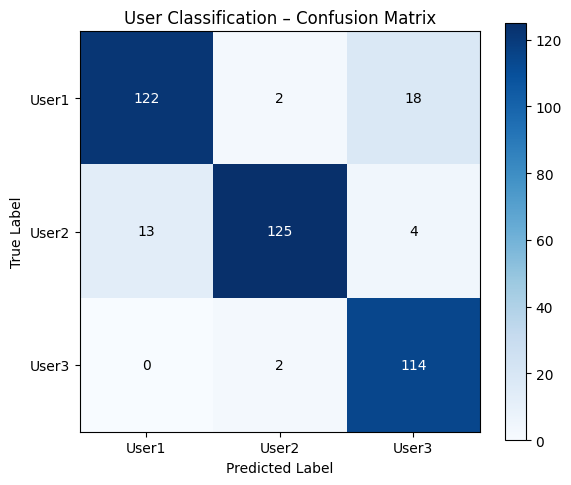

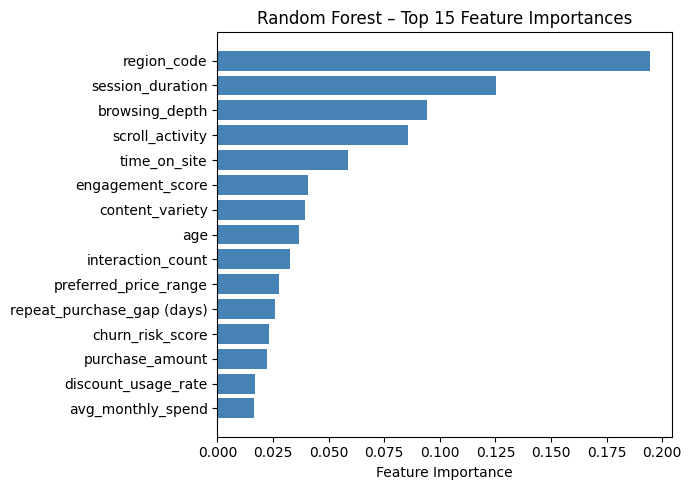

In [ ]:
X_all = train_users[feature_cols].values
y_all = train_users["label_encoded"].values

X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

print(f"Train size: {X_train.shape[0]}, Validation size: {X_val.shape[0]}")

clf = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_val)
val_accuracy = accuracy_score(y_val, y_pred)

print(f"\nUser Classification Accuracy (validation set): {val_accuracy:.4f}\n")
print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=user_label_encoder.classes_))

cm = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:")
print(cm)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(
    xticks=np.arange(cm.shape[1]),
    yticks=np.arange(cm.shape[0]),
    xticklabels=user_label_encoder.classes_,
    yticklabels=user_label_encoder.classes_,
    ylabel="True Label",
    xlabel="Predicted Label",
    title="User Classification – Confusion Matrix",
)
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()

# Feature importance (top 15)
importances = clf.feature_importances_
sorted_idx = np.argsort(importances)[-15:]
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(np.array(feature_cols)[sorted_idx], importances[sorted_idx], color="steelblue")
ax.set_xlabel("Feature Importance")
ax.set_title("Random Forest – Top 15 Feature Importances")
plt.tight_layout()
plt.show()


# `Contextual Bandit`

## Reward Sampler Initialization

The sampler is initialized using the student's roll number `i`.
Rewards are obtained using `sampler.sample(j)`.


## Arm Mapping

| Arm Index (j) | News Category | User Context |
|--------------|---------------|--------------|
| 0–3          | Entertainment, Education, Tech, Crime | User1 |
| 4–7          | Entertainment, Education, Tech, Crime | User2 |
| 8–11         | Entertainment, Education, Tech, Crime | User3 |

## Epsilon-Greedy Strategy

This section implements the epsilon-greedy contextual bandit algorithm.


## Upper Confidence Bound (UCB)

This section implements the UCB strategy for contextual bandits.

## SoftMax Strategy

This section implements the SoftMax strategy with temperature $ \tau = 1$.


## Reinforcement Learning Simulation

We simulate the bandit algorithms for $T = 10,000$ steps and record rewards.

P.S.: Change $T$ value as and if required.


## Results and Analysis

This section presents:
- Average Reward vs Time
- Hyperparameter comparisons
- Observations and discussion


## Final Observations

- Comparison of Epsilon-Greedy, UCB, and SoftMax
- Effect of hyperparameters
- Strengths and limitations of each approach
